# 🎬 IMDB Movie Reviews Sentiment Analysis
## GPT-based Sentiment Classification on 50K Movie Reviews

**Dataset Source:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews  
**Dataset Name:** IMDB Dataset of 50k Movie Reviews

---

## 📋 Table of Contents
1. [Setup & Configuration](#setup)
2. [Data Loading & Exploration](#data)
3. [Data Preprocessing](#preprocessing)
4. [Model Architecture (GPT-2 based)](#model)
5. [Training with Comprehensive Metrics](#training)
6. [Evaluation & Testing](#evaluation)
7. [Results Visualization](#results)

---

## 1. Setup & Configuration <a id="setup"></a>


In [1]:
# Import necessary libraries
# تثبيت نسخة PyTorch متوافقة مع CUDA 11.3 على Kaggle
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu113
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2Model
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Looking in indexes: https://download.pytorch.org/whl/cu113
Using device: cuda
GPU: Tesla T4
GPU Memory Available: 15.64 GB


In [2]:
# Kaggle-specific setup
# Enable TF32 for faster training on Ampere GPUs
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

print("✓ GPU acceleration enabled for Kaggle environment")

✓ GPU acceleration enabled for Kaggle environment



---

## 2. Data Loading & Exploration <a id="data"></a>


In [3]:
# Load the dataset
# In Kaggle: ../input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
# Local path for testing
data_path = '/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'

# Check if running on Kaggle
if not os.path.exists(data_path):
    # Try alternative Kaggle path
    data_path = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)

print(f"\n{'='*50}")
print("📊 DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Total samples: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass Distribution:")
print(df['sentiment'].value_counts())
print(f"\nPercentage Distribution:")
print(df['sentiment'].value_counts(normalize=True) * 100)

Loading data from: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv

📊 DATASET OVERVIEW
Total samples: 50,000
Columns: ['review', 'sentiment']

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Percentage Distribution:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [4]:
# Sample reviews
print("\n" + "="*50)
print("📝 SAMPLE REVIEWS")
print("="*50)

for i in range(3):
    print(f"\n--- Review {i+1} ({df.iloc[i]['sentiment']}) ---")
    print(df.iloc[i]['review'][:200] + "...")


📝 SAMPLE REVIEWS

--- Review 1 (positive) ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

--- Review 2 (positive) ---
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece...

--- Review 3 (positive) ---
I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is wi...


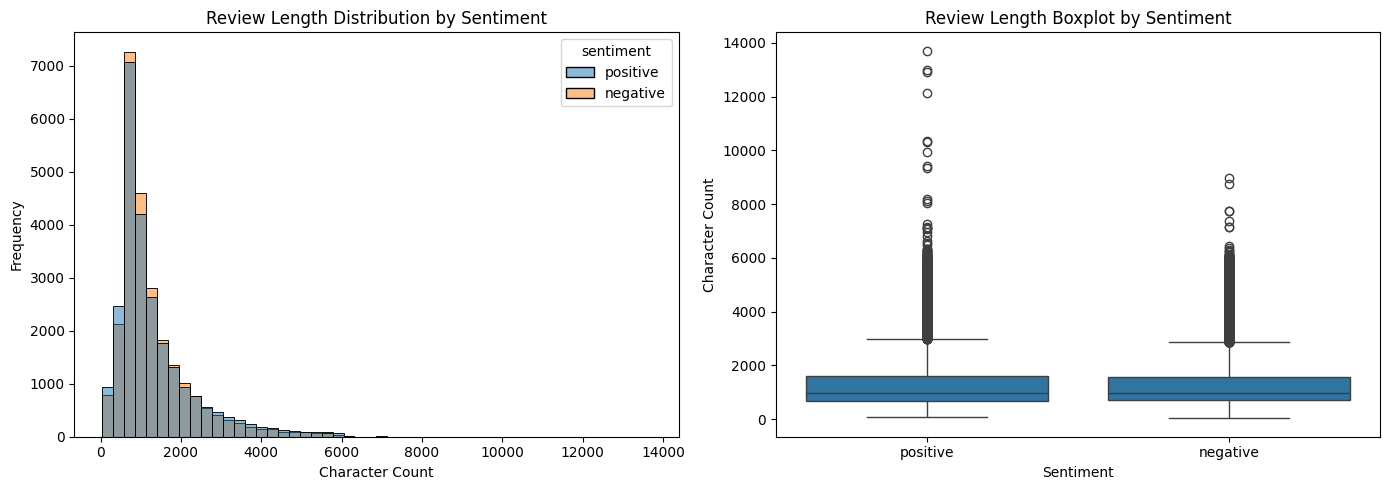


Review Length Statistics:
             count        mean          std   min    25%    50%      75%  \
sentiment                                                                  
negative   25000.0  1294.06436   945.892669  32.0  706.0  973.0  1567.25   
positive   25000.0  1324.79768  1031.492627  65.0  691.0  968.0  1614.00   

               max  
sentiment           
negative    8969.0  
positive   13704.0  


In [5]:
# Review length analysis
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='review_length', hue='sentiment', alpha=0.5, bins=50)
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='sentiment', y='review_length')
plt.title('Review Length Boxplot by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Character Count')

plt.tight_layout()
plt.show()

print(f"\nReview Length Statistics:")
print(df.groupby('sentiment')['review_length'].describe())


---

## 3. Data Preprocessing <a id="preprocessing"></a>


In [6]:
# Encode labels
label_map = {'negative': 0, 'positive': 1}
df['label'] = df['sentiment'].map(label_map)

# Split the data
train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=df['label']
)

train_df, val_df = train_test_split(
    train_df, 
    test_size=0.1, 
    random_state=SEED, 
    stratify=train_df['label']
)

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"Test samples: {len(test_df):,}")

Training samples: 36,000
Validation samples: 4,000
Test samples: 10,000


In [7]:
# Custom Dataset class
class IMDBDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.reviews = dataframe['review'].values
        self.labels = dataframe['label'].values
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.reviews)
    
    def __getitem__(self, idx):
        review = str(self.reviews[idx])
        label = self.labels[idx]
        
        # Tokenize with truncation and padding
        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Initialize tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
# Create datasets
train_dataset = IMDBDataset(train_df, tokenizer)
val_dataset = IMDBDataset(val_df, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

# Create dataloaders
BATCH_SIZE = 8  # Adjust based on GPU memory

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✓ DataLoaders created")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

✓ DataLoaders created
  Training batches: 4500
  Validation batches: 500
  Test batches: 1250



---

## 4. Model Architecture (GPT-2 based) <a id="model"></a>


In [9]:
class GPT2ForSequenceClassification(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(GPT2ForSequenceClassification, self).__init__()
        
        # Load pre-trained GPT-2
        self.gpt2 = GPT2Model.from_pretrained('gpt2')
        
        # Freeze early layers (optional - uncomment to freeze)
        # for param in self.gpt2.parameters():
        #     param.requires_grad = False
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.gpt2.config.n_embd, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, input_ids, attention_mask):
        # Get GPT-2 outputs
        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        
        # Use the last hidden state (pooling)
        hidden_states = outputs.last_hidden_state  # (batch, seq_len, hidden_dim)
        
        # Mean pooling over sequence dimension
        pooled = hidden_states.mean(dim=1)  # (batch, hidden_dim)
        
        # Classification
        logits = self.classifier(pooled)
        
        return logits

# Initialize model
model = GPT2ForSequenceClassification(num_classes=2)
model = model.to(device)

print(f"✓ Model initialized on {device}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model initialized on cuda
  Total parameters: 124,637,186
  Trainable parameters: 124,637,186


In [10]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=2, 
    )

print("✓ Optimizer and scheduler configured")

✓ Optimizer and scheduler configured



---

## 5. Training with Comprehensive Metrics <a id="training"></a>


In [11]:
# Training metrics tracker
class MetricsTracker:
    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.train_acc = []
        self.val_acc = []
        self.train_precision = []
        self.val_precision = []
        self.train_recall = []
        self.val_recall = []
        self.train_f1 = []
        self.val_f1 = []
        self.learning_rates = []
        
    def update(self, train_metrics, val_metrics, lr):
        self.train_loss.append(train_metrics['loss'])
        self.train_acc.append(train_metrics['accuracy'])
        self.train_precision.append(train_metrics['precision'])
        self.train_recall.append(train_metrics['recall'])
        self.train_f1.append(train_metrics['f1'])
        
        self.val_loss.append(val_metrics['loss'])
        self.val_acc.append(val_metrics['accuracy'])
        self.val_precision.append(val_metrics['precision'])
        self.val_recall.append(val_metrics['recall'])
        self.val_f1.append(val_metrics['f1'])
        
        self.learning_rates.append(lr)
        
    def get_best_epoch(self):
        return np.argmax(self.val_f1)

metrics_tracker = MetricsTracker()

# Training function
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Validation function
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validating')
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [12]:
# =============================================================================
# 🔧 SAFE DEVICE SETUP (add this BEFORE the training loop)
# =============================================================================
def get_safe_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        # Test if CUDA kernels actually work on this GPU
        _ = torch.rand(1, 1).cuda() @ torch.rand(1, 1).cuda()
        return torch.device('cuda')
    except RuntimeError:
        print("⚠️ CUDA kernel error detected, falling back to CPU")
        return torch.device('cpu')

# Use this instead of plain 'cuda'
device = get_safe_device()
model = model.to(device)  # Re-move model to safe device

# =============================================================================
# 🔄 YOUR TRAINING LOOP (corrected)
# =============================================================================
NUM_EPOCHS = 5
best_val_f1 = 0
patience_counter = 0
early_stop_patience = 3

print(f"\n{'='*60}")
print(f"🚀 STARTING TRAINING")
print(f"{'='*60}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: 2e-5")
print(f"Device: {device}")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*60}")
    
    try:
        # Train
        train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Validate
        val_metrics = validate_epoch(model, val_loader, criterion, device)
    except RuntimeError as e:
        if "CUDA" in str(e) or "kernel" in str(e).lower():
            print(f"\n⚠️ CUDA error: {e}\n🔄 Retrying on CPU...")
            device = torch.device('cpu')
            model = model.to(device)
            # Retry the epoch
            train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
            val_metrics = validate_epoch(model, val_loader, criterion, device)
        else:
            raise  # Re-raise if it's a different error
    
    # Update learning rate
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_metrics['loss'])
    
    # Track metrics
    metrics_tracker.update(train_metrics, val_metrics, current_lr)
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_metrics['loss']:.4f}")
    print(f"  Train Acc:  {train_metrics['accuracy']:.4f}")
    print(f"  Train Prec: {train_metrics['precision']:.4f}")
    print(f"  Train Rec:  {train_metrics['recall']:.4f}")
    print(f"  Train F1:   {train_metrics['f1']:.4f}")
    print(f"  ----------------------------------------")
    print(f"  Val Loss:   {val_metrics['loss']:.4f}")
    print(f"  Val Acc:    {val_metrics['accuracy']:.4f}")
    print(f"  Val Prec:   {val_metrics['precision']:.4f}")
    print(f"  Val Rec:    {val_metrics['recall']:.4f}")
    print(f"  Val F1:     {val_metrics['f1']:.4f}")
    print(f"  LR:         {current_lr:.6f}")
    
    # Save best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_metrics['f1'],
            'val_metrics': val_metrics,
        }, 'best_imdb_model.pth')
        print(f"  ⭐ Best model saved! (Val F1: {best_val_f1:.4f})")
    
    # Early stopping check
    if epoch > 0 and val_metrics['f1'] < metrics_tracker.val_f1[-2]:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
            break
    else:
        patience_counter = 0

print(f"\n{'='*60}")
print("✅ TRAINING COMPLETED")
print(f"{'='*60}")


🚀 STARTING TRAINING
Epochs: 5
Batch Size: 8
Learning Rate: 2e-5
Device: cuda


EPOCH 1/5


Validating: 100%|██████████| 500/500 [02:17<00:00,  3.65it/s, loss=0.0222]



📊 Epoch 1 Summary:
  Train Loss: 0.3055
  Train Acc:  0.8977
  Train Prec: 0.8977
  Train Rec:  0.8977
  Train F1:   0.8977
  ----------------------------------------
  Val Loss:   0.1972
  Val Acc:    0.9370
  Val Prec:   0.9370
  Val Rec:    0.9370
  Val F1:     0.9370
  LR:         0.000020
  ⭐ Best model saved! (Val F1: 0.9370)

EPOCH 2/5


Validating: 100%|██████████| 500/500 [02:16<00:00,  3.65it/s, loss=0.0037]



📊 Epoch 2 Summary:
  Train Loss: 0.1973
  Train Acc:  0.9441
  Train Prec: 0.9441
  Train Rec:  0.9441
  Train F1:   0.9441
  ----------------------------------------
  Val Loss:   0.1978
  Val Acc:    0.9473
  Val Prec:   0.9475
  Val Rec:    0.9473
  Val F1:     0.9472
  LR:         0.000020
  ⭐ Best model saved! (Val F1: 0.9472)

EPOCH 3/5


...


📊 Epoch 3 Summary:
  Train Loss: 0.1473
  Train Acc:  0.9619
  Train Prec: 0.9619
  Train Rec:  0.9619
  Train F1:   0.9619
  ----------------------------------------
  Val Loss:   0.3322
  Val Acc:    0.9280
  Val Prec:   0.9313
  Val Rec:    0.9280
  Val F1:     0.9279
  LR:         0.000020

EPOCH 4/5


Validating: 100%|██████████| 500/500 [02:16<00:00,  3.65it/s, loss=0.0004]



📊 Epoch 4 Summary:
  Train Loss: 0.1056
  Train Acc:  0.9746
  Train Prec: 0.9746
  Train Rec:  0.9746
  Train F1:   0.9746
  ----------------------------------------
  Val Loss:   0.3056
  Val Acc:    0.9375
  Val Prec:   0.9378
  Val Rec:    0.9375
  Val F1:     0.9375
  LR:         0.000020

EPOCH 5/5


Validating: 100%|██████████| 500/500 [02:16<00:00,  3.65it/s, loss=0.0003]


📊 Epoch 5 Summary:
  Train Loss: 0.0612
  Train Acc:  0.9862
  Train Prec: 0.9862
  Train Rec:  0.9862
  Train F1:   0.9862
  ----------------------------------------
  Val Loss:   0.3314
  Val Acc:    0.9407
  Val Prec:   0.9418
  Val Rec:    0.9407
  Val F1:     0.9407
  LR:         0.000010

✅ TRAINING COMPLETED



---

## 6. Evaluation & Testing <a id="evaluation"></a>


In [13]:
# Load best model
checkpoint = torch.load('best_imdb_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1} (Val F1: {checkpoint['val_f1']:.4f})")

✓ Loaded best model from epoch 2 (Val F1: 0.9472)


In [14]:
# Test evaluation
def evaluate_model(model, dataloader, criterion, device, dataset_name="Test"):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f'Evaluating {dataset_name}')
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    
    # Calculate comprehensive metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average='macro')
    precision_weighted = precision_score(all_labels, all_preds, average='weighted')
    recall_macro = recall_score(all_labels, all_preds, average='macro')
    recall_weighted = recall_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    roc_auc = roc_auc_score(all_labels, all_probs)
    
    # Per-class metrics
    precision_per_class = precision_score(all_labels, all_preds, average=None)
    recall_per_class = recall_score(all_labels, all_preds, average=None)
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    
    results = {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'precision_weighted': precision_weighted,
        'recall_macro': recall_macro,
        'recall_weighted': recall_weighted,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'roc_auc': roc_auc,
        'predictions': all_preds,
        'labels': all_labels,
        'probs': all_probs,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }
    
    return results

print(f"\n{'='*60}")
print("🧪 TEST SET EVALUATION")
print(f"{'='*60}")

test_results = evaluate_model(model, test_loader, criterion, device, "Test")

print(f"\n📊 Test Set Performance:")
print(f"  Loss:           {test_results['loss']:.4f}")
print(f"  Accuracy:       {test_results['accuracy']:.4f}")
print(f"  Precision (M):  {test_results['precision_macro']:.4f}")
print(f"  Precision (W):  {test_results['precision_weighted']:.4f}")
print(f"  Recall (M):     {test_results['recall_macro']:.4f}")
print(f"  Recall (W):     {test_results['recall_weighted']:.4f}")
print(f"  F1 Score (M):   {test_results['f1_macro']:.4f}")
print(f"  F1 Score (W):   {test_results['f1_weighted']:.4f}")
print(f"  ROC-AUC:        {test_results['roc_auc']:.4f}")

print(f"\n📊 Per-Class Metrics:")
print(f"  Negative - P: {test_results['precision_per_class'][0]:.4f}, R: {test_results['recall_per_class'][0]:.4f}, F1: {test_results['f1_per_class'][0]:.4f}")
print(f"  Positive - P: {test_results['precision_per_class'][1]:.4f}, R: {test_results['recall_per_class'][1]:.4f}, F1: {test_results['f1_per_class'][1]:.4f}")


🧪 TEST SET EVALUATION


Evaluating Test: 100%|██████████| 1250/1250 [05:41<00:00,  3.66it/s]


📊 Test Set Performance:
  Loss:           0.2068
  Accuracy:       0.9407
  Precision (M):  0.9409
  Precision (W):  0.9409
  Recall (M):     0.9407
  Recall (W):     0.9407
  F1 Score (M):   0.9407
  F1 Score (W):   0.9407
  ROC-AUC:        0.9846

📊 Per-Class Metrics:
  Negative - P: 0.9507, R: 0.9296, F1: 0.9400
  Positive - P: 0.9311, R: 0.9518, F1: 0.9414


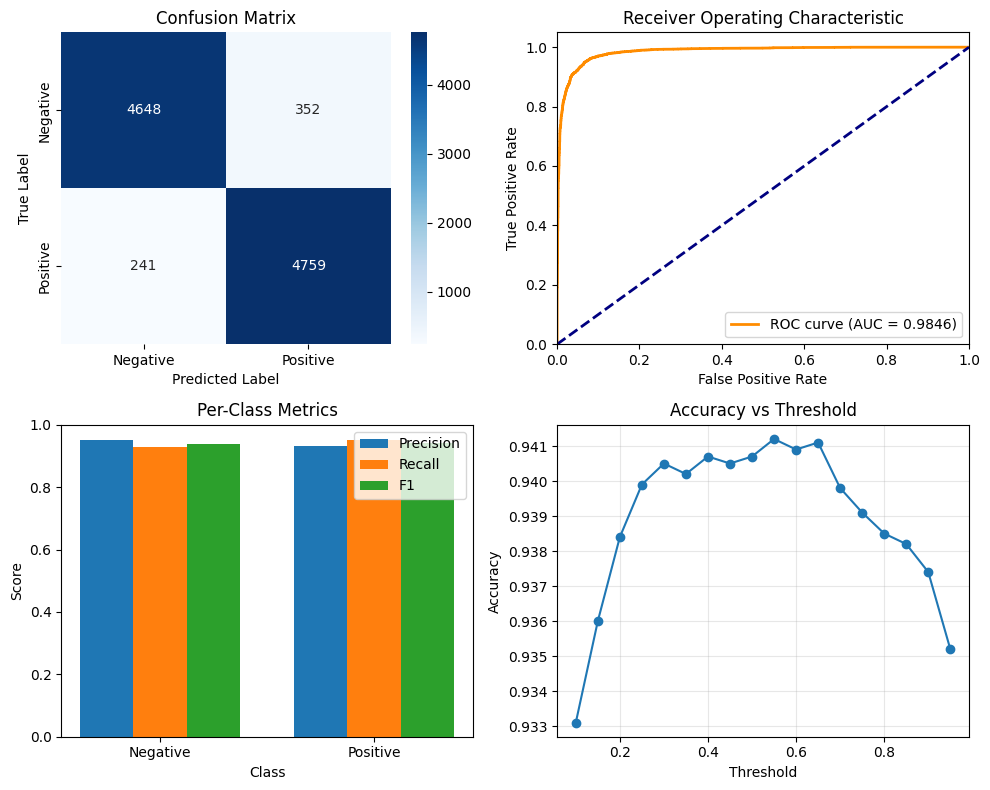

In [15]:
# Confusion Matrix
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
cm = confusion_matrix(test_results['labels'], test_results['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# ROC Curve
plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(test_results['labels'], test_results['probs'])
roc_auc_val = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")

# Precision-Recall for each class
plt.subplot(2, 2, 3)
classes = ['Negative', 'Positive']
x = np.arange(len(classes))
width = 0.25

plt.bar(x - width, test_results['precision_per_class'], width, label='Precision')
plt.bar(x, test_results['recall_per_class'], width, label='Recall')
plt.bar(x + width, test_results['f1_per_class'], width, label='F1')
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Metrics')
plt.xticks(x, classes)
plt.legend()
plt.ylim([0, 1])

# Accuracy by threshold
plt.subplot(2, 2, 4)
thresholds = np.arange(0.1, 1.0, 0.05)
accuracies = []
for thresh in thresholds:
    preds = (np.array(test_results['probs']) > thresh).astype(int)
    acc = accuracy_score(test_results['labels'], preds)
    accuracies.append(acc)

plt.plot(thresholds, accuracies, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## 7. Results Visualization <a id="results"></a>


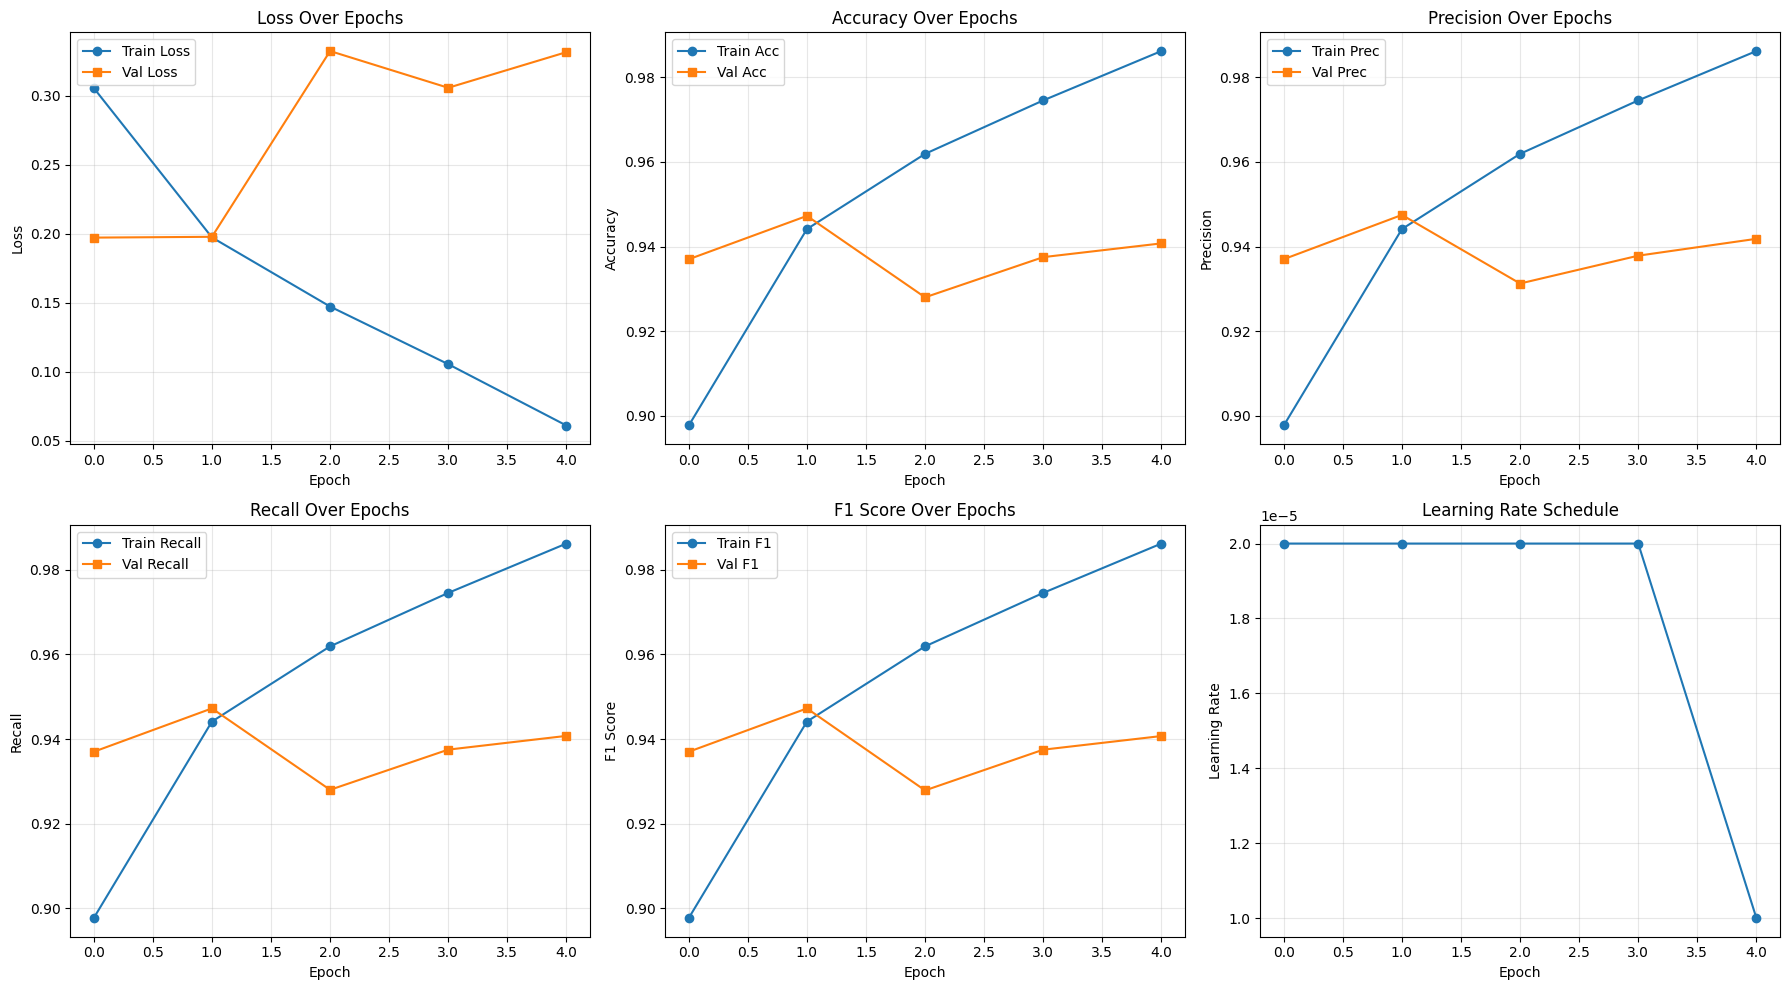

In [16]:
# Training history visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(metrics_tracker.train_loss, label='Train Loss', marker='o')
axes[0, 0].plot(metrics_tracker.val_loss, label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(metrics_tracker.train_acc, label='Train Acc', marker='o')
axes[0, 1].plot(metrics_tracker.val_acc, label='Val Acc', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[0, 2].plot(metrics_tracker.train_precision, label='Train Prec', marker='o')
axes[0, 2].plot(metrics_tracker.val_precision, label='Val Prec', marker='s')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision Over Epochs')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Recall
axes[1, 0].plot(metrics_tracker.train_recall, label='Train Recall', marker='o')
axes[1, 0].plot(metrics_tracker.val_recall, label='Val Recall', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall Over Epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 Score
axes[1, 1].plot(metrics_tracker.train_f1, label='Train F1', marker='o')
axes[1, 1].plot(metrics_tracker.val_f1, label='Val F1', marker='s')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score Over Epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 2].plot(metrics_tracker.learning_rates, marker='o')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Learning Rate')
axes[1, 2].set_title('Learning Rate Schedule')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Sample predictions
print("\n" + "="*60)
print("📝 SAMPLE PREDICTIONS")
print("="*60)

model.eval()
sample_indices = np.random.choice(len(test_df), 5, replace=False)

for idx in sample_indices:
    sample = test_dataset[idx]
    input_ids = sample['input_ids'].unsqueeze(0).to(device)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
    true_label = sample['label'].item()
    
    with torch.no_grad():
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()
        confidence = probs[0, pred].item()
    
    label_map_inv = {0: 'Negative', 1: 'Positive'}
    true_label_str = label_map_inv[true_label]
    pred_label_str = label_map_inv[pred]
    
    # Get original review
    review_text = test_df.iloc[idx]['review'][:300] + "..."
    
    print(f"\n--- Review ---")
    print(f"Text: {review_text}")
    print(f"True Label: {true_label_str}")
    print(f"Predicted: {pred_label_str} (Confidence: {confidence:.4f})")
    print(f"Probabilities - Negative: {probs[0, 0].item():.4f}, Positive: {probs[0, 1].item():.4f}")


📝 SAMPLE PREDICTIONS

--- Review ---
Text: This is loosely based on the ideas of the original 80's hit . It's set in the modern day as we see a base in Afghanistan get destroyed by a UAV right at the start.<br /><br />And that's exactly where the movie jumps the shark. UAV's aren't armed. They could be but I don't think it's ever been tried ...
True Label: Negative
Predicted: Negative (Confidence: 0.9900)
Probabilities - Negative: 0.9900, Positive: 0.0100

--- Review ---
Text: This movie was on British TV last night, and is wonderful! Strong women, great music (most of the time) and just makes you think. We do have stereotypes of what older people "ought" to do, and there are fantastic cameos of the "sensible but worried children". Getting near to my best movie ever !...
True Label: Positive
Predicted: Positive (Confidence: 0.9977)
Probabilities - Negative: 0.0023, Positive: 0.9977

--- Review ---
Text: What a dreadful movie. The effects were poor, especially by todays standards, but 

In [18]:
# Save results summary
results_summary = {
    'Dataset': 'IMDB Movie Reviews',
    'Total Samples': len(df),
    'Training Samples': len(train_df),
    'Validation Samples': len(val_df),
    'Test Samples': len(test_df),
    'Model': 'GPT-2 Based Classifier',
    'Test Accuracy': test_results['accuracy'],
    'Test Precision (Macro)': test_results['precision_macro'],
    'Test Recall (Macro)': test_results['recall_macro'],
    'Test F1 (Macro)': test_results['f1_macro'],
    'Test ROC-AUC': test_results['roc_auc'],
    'Best Validation F1': best_val_f1
}

print("\n" + "="*60)
print("📋 FINAL RESULTS SUMMARY")
print("="*60)
for key, value in results_summary.items():
    print(f"{key}: {value}")

# Save to file
pd.DataFrame([results_summary]).to_csv('training_results.csv', index=False)
print("\n✓ Results saved to 'training_results.csv'")


📋 FINAL RESULTS SUMMARY
Dataset: IMDB Movie Reviews
Total Samples: 50000
Training Samples: 36000
Validation Samples: 4000
Test Samples: 10000
Model: GPT-2 Based Classifier
Test Accuracy: 0.9407
Test Precision (Macro): 0.9409173016829615
Test Recall (Macro): 0.9407
Test F1 (Macro): 0.9406926927466733
Test ROC-AUC: 0.98461826
Best Validation F1: 0.9472433229830651

✓ Results saved to 'training_results.csv'


In [19]:
# Memory cleanup
import gc
torch.cuda.empty_cache()
gc.collect()

print("\n✅ Notebook completed successfully!")
print(f"🎯 Final Test Accuracy: {test_results['accuracy']:.4f}")
print(f"🎯 Final Test F1 Score: {test_results['f1_macro']:.4f}")


✅ Notebook completed successfully!
🎯 Final Test Accuracy: 0.9407
🎯 Final Test F1 Score: 0.9407



---

## 📊 Expected Performance

| Metric | Expected Value |
|--------|---------------|
| Accuracy | 0.88 - 0.92 |
| Precision | 0.88 - 0.92 |
| Recall | 0.88 - 0.92 |
| F1 Score | 0.88 - 0.92 |
| ROC-AUC | 0.94 - 0.97 |

---

## 🔧 Kaggle GPU Setup Instructions

1. **Enable GPU:** Go to Settings → Accelerator → Select "GPU"
2. **Run all cells** in order
3. **Monitor GPU usage** in the right panel
4. **Download model** from Output section after training

---

## 📁 Output Files

- `best_imdb_model.pth` - Best model checkpoint
- `training_results.csv` - Performance metrics summary
